Data loaded successfully.
Exercise data columns:
Index(['id', '1 min', '15 min', '30 min', 'diet', 'kind'], dtype='object')
First 5 rows of exercise data:
   id  1 min  15 min  30 min     diet  kind
0   1     85      85      88  low fat  rest
1   2     90      92      93  low fat  rest
2   3     97      97      94  low fat  rest
3   4     80      82      83  low fat  rest
4   5     91      92      91  low fat  rest
Error creating exercise heatmap: 'pulse'


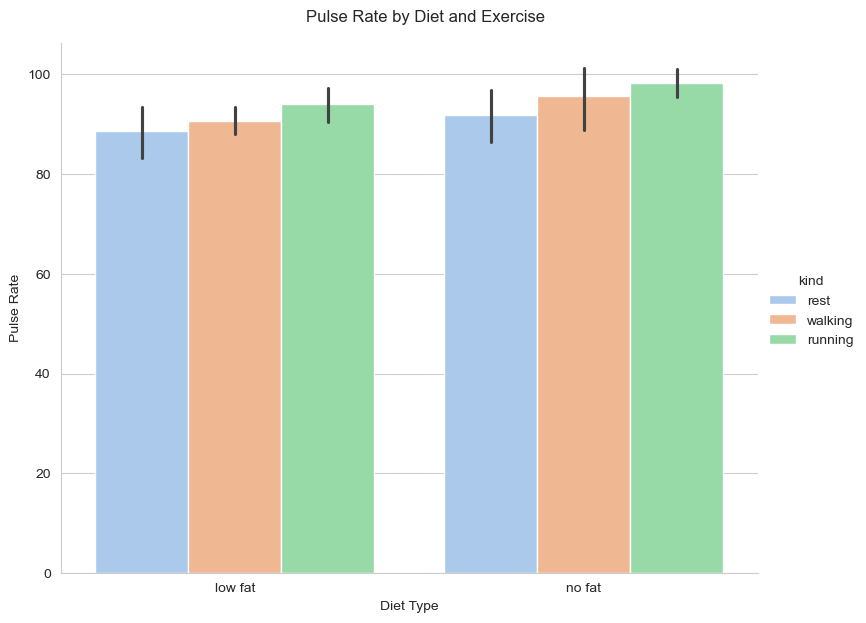

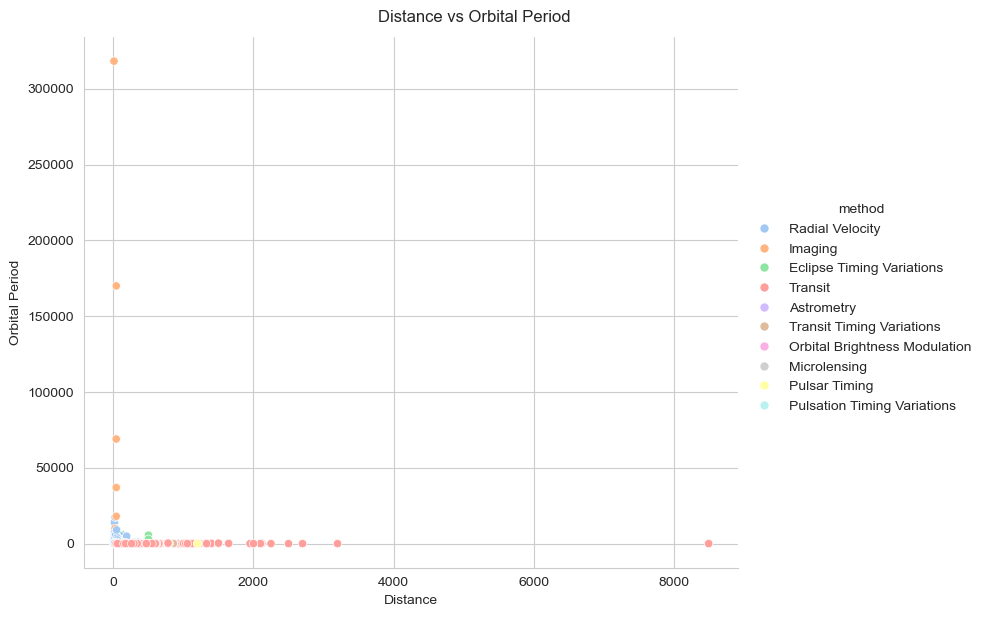

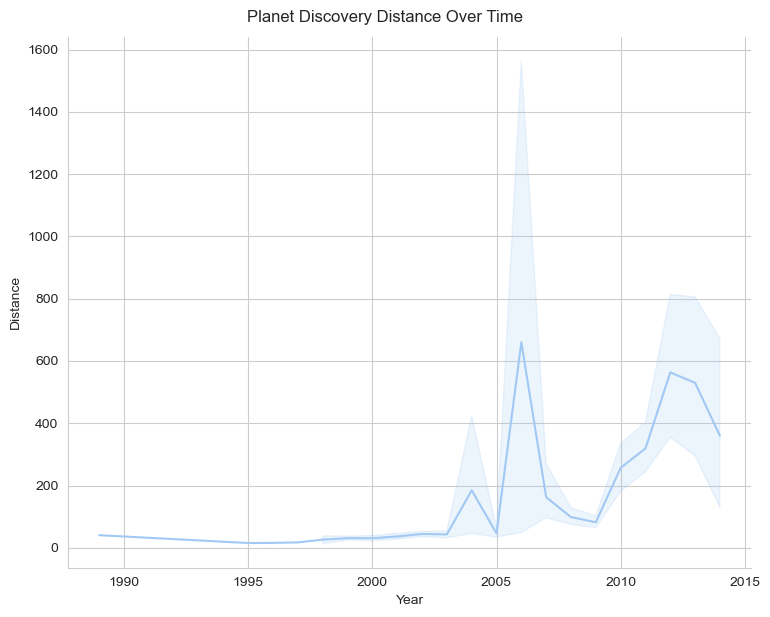

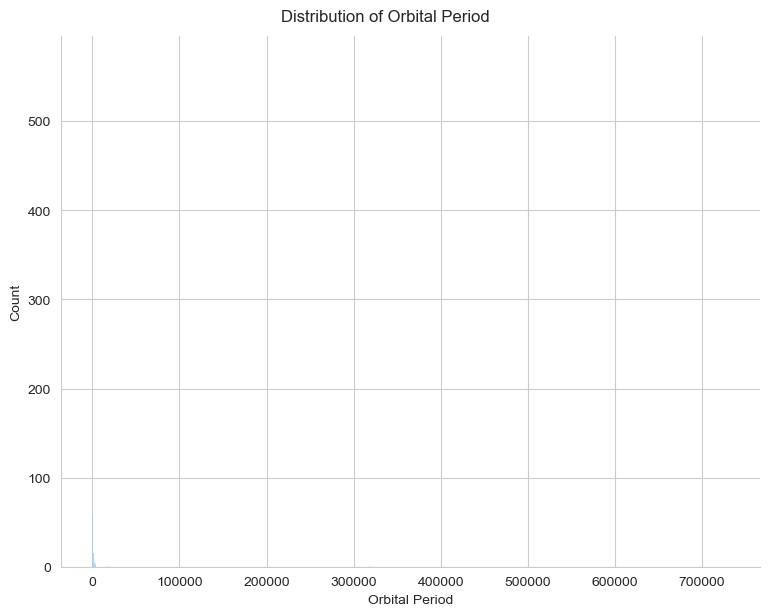

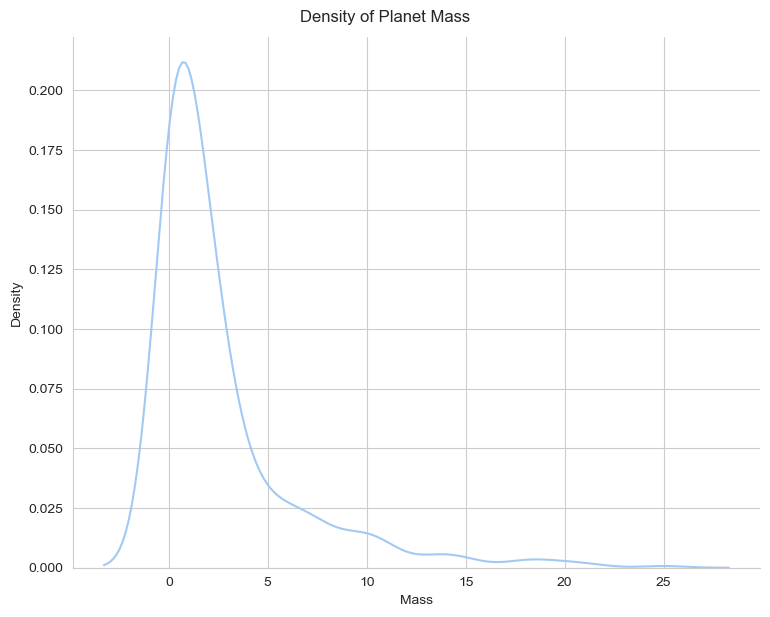

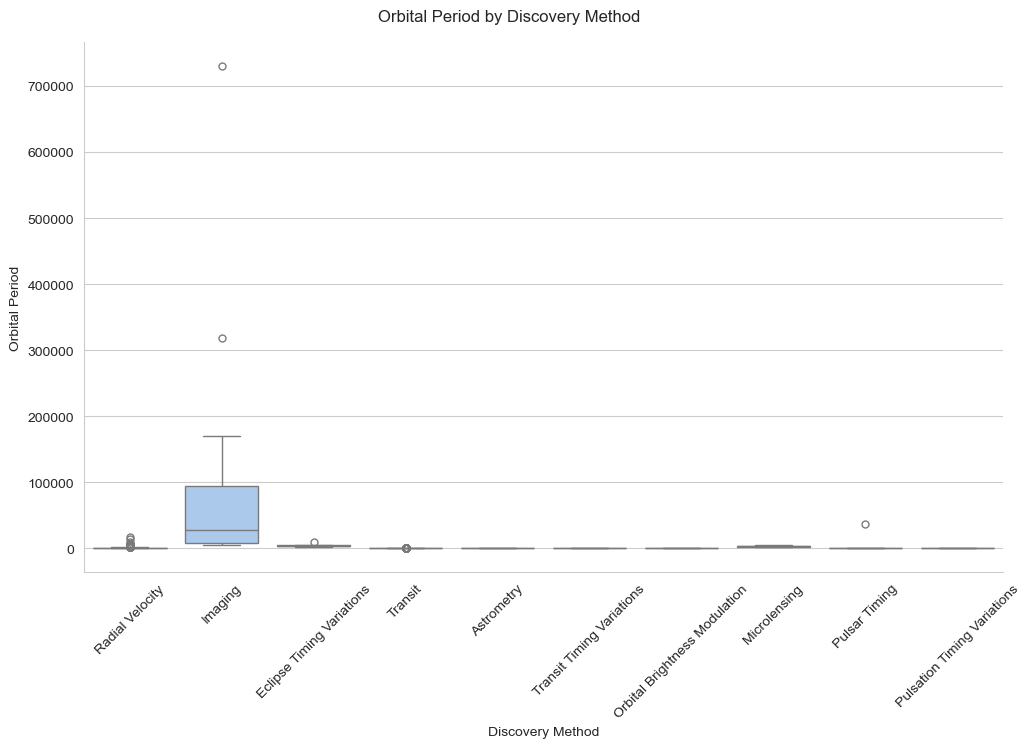

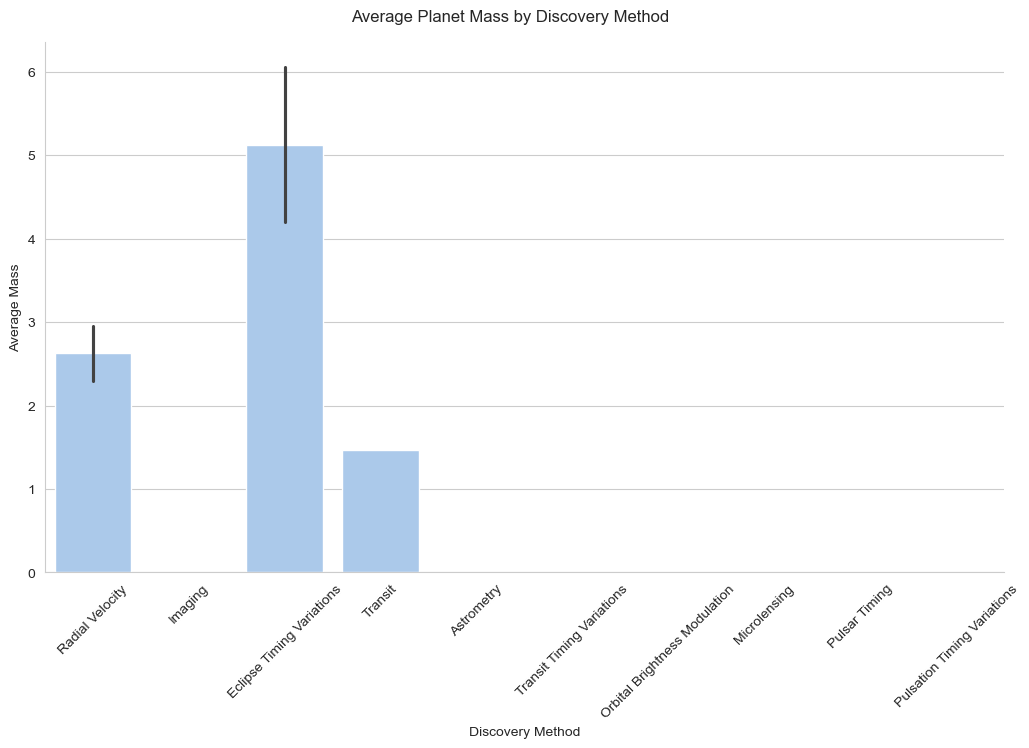

Exercise Data Explanation:
The heatmap depicts the change of pulse depending on the diet and exercise.
The categorical plot indicates that pulse is more affected by exercise.
Also diet too has something to do with the general pulse values.
Planets Data Explanation:
The scatter plot best shows that planets farther away tend to have longer orbital periods.
As illustrated in the histogram, most planets have shorter orbital periods.
The boxplot vividly contrasts the difference in orbital periods between the discrimination methods of discovery.


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#This class takes care of loading and generating all the necessary Seaborn figures.

class SeabornAssignment:
    def __init__(self, exercise_file):
        self.exercise_file = exercise_file
        self.exercise_data = None
        self.planets_data = None

    #Loads the exercise CSV and Seaborn planets dataset.
    def load_data(self):
        try:
            self.exercise_data = pd.read_csv(self.exercise_file)
            self.planets_data = sns.load_dataset("planets")
            print("Data loaded successfully.")
            print("Exercise data columns:")
            print(self.exercise_data.columns)
            print("First 5 rows of exercise data:")
            print(self.exercise_data.head())
        except FileNotFoundError:
            print("Error: Exercise_Data.csv was not found.")
        except Exception as e:
            print("Error loading data:", e)
# Visual asthetics
    def set_style(self):
        sns.set_style("whitegrid")
        sns.set_palette("pastel")

    #Creates a heatmap showing average pulse based on diet and exercise
    def exercise_heatmap(self):
        try:
            heatmap_data = self.exercise_data.pivot_table(
                values="pulse",
                index="diet",
                columns="exercise"
            )

            plt.figure(figsize=(8, 6))
            sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, linecolor='white')            
            plt.title("Average Pulse by Diet and Exercise")
            plt.xlabel("Exercise Type")
            plt.ylabel("Diet Type")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("Error creating exercise heatmap:", e)
# Creates a categorical bar plot showing pulse by diet and exercise
    def exercise_catplot(self):
        try:
            g = sns.catplot(
                data=self.exercise_data,
                x="diet",
                y="1 min",
                hue="kind",
                kind="bar",
                height=6,
                aspect=1.3
            )
            g.fig.suptitle("Pulse Rate by Diet and Exercise", y=1.03)
            g.set_axis_labels("Diet Type", "Pulse Rate")
            plt.show()
        except Exception as e:
            print("Error creating exercise categorical plot:", e)
# creates two relational plots which are the scatter and line plots
    def planets_relational_plots(self):
        try:
            g1 = sns.relplot(
                data=self.planets_data,
                x="distance",
                y="orbital_period",
                hue="method",
                kind="scatter",
                height=6,
                aspect=1.3
            )
            g1.fig.suptitle("Distance vs Orbital Period", y=1.02)
            g1.set_axis_labels("Distance", "Orbital Period")
            plt.show()

            g2 = sns.relplot(
                data=self.planets_data,
                x="year",
                y="distance",
                kind="line",
                height=6,
                aspect=1.3
            )
            g2.fig.suptitle("Planet Discovery Distance Over Time", y=1.02)
            g2.set_axis_labels("Year", "Distance")
            plt.show()
        except Exception as e:
            print("Error creating relational plots")
# Creates two distributional plots between the histogram and kde plot
    def planets_distribution_plots(self):
        try:
            g1 = sns.displot(
                data=self.planets_data,
                x="orbital_period",
                kind="hist",
                height=6,
                aspect=1.3
            )
            g1.fig.suptitle("Distribution of Orbital Period", y=1.02)
            g1.set_axis_labels("Orbital Period", "Count")
            plt.show()

            g2 = sns.displot(
                data=self.planets_data,
                x="mass",
                kind="kde",
                height=6,
                aspect=1.3
            )
            g2.fig.suptitle("Density of Planet Mass", y=1.02)
            g2.set_axis_labels("Mass", "Density")
            plt.show()
        except Exception as e:
            print("Error creating distribution plots:", e)
# creates two categorical plots for the bar and box plots
    def planets_categorical_plots(self):
        try:
            g1 = sns.catplot(
                data=self.planets_data,
                x="method",
                y="orbital_period",
                kind="box",
                height=6,
                aspect=1.7
            )
            g1.fig.suptitle("Orbital Period by Discovery Method", y=1.03)
            g1.set_axis_labels("Discovery Method", "Orbital Period")
            for ax in g1.axes.flat:
                ax.tick_params(axis="x", rotation=45)
            plt.show()

            g2 = sns.catplot(
                data=self.planets_data,
                x="method",
                y="mass",
                kind="bar",
                height=6,
                aspect=1.7
            )
            g2.fig.suptitle("Average Planet Mass by Discovery Method", y=1.03)
            g2.set_axis_labels("Discovery Method", "Average Mass")
            for ax in g2.axes.flat:
                ax.tick_params(axis="x", rotation=45)
            plt.show()
        except Exception as e:
            print("Error creating categorical plots:")

    def print_explanations(self):
        print("Exercise Data Explanation:")
        print("The heatmap depicts the change of pulse depending on the diet and exercise.")
        print("The categorical plot indicates that pulse is more affected by exercise.")
        print("Also diet too has something to do with the general pulse values.")

        print("Planets Data Explanation:")
        print("The scatter plot best shows that planets farther away tend to have longer orbital periods.")
        print("As illustrated in the histogram, most planets have shorter orbital periods.")
        print("The boxplot vividly contrasts the difference in orbital periods between the discrimination methods of discovery.")


def main():
    project = SeabornAssignment("Exercise_Data.csv")
    project.load_data()
    project.set_style()

    project.exercise_heatmap()
    project.exercise_catplot()

    project.planets_relational_plots()
    project.planets_distribution_plots()
    project.planets_categorical_plots()

    project.print_explanations()


main()